# EDA - PetFinder Adoption Prediction

Análisis exploratorio del dataset de entrenamiento de la competencia de Kaggle [PetFinder.my Adoption Prediction](https://www.kaggle.com/c/petfinder-adoption-prediction).

**Objetivo:** Comprender la estructura y distribución de los datos como punto de partida para el entrenamiento de un modelo predictivo de `AdoptionSpeed`, una variable objetivo ordinal con clases de 0 a 4, donde valores más bajos indican adopciones más rápidas.

**Estructura del análisis:**
1. Carga y limpieza inicial
2. Análisis univariado
3. Análisis bivariado (relación con el target)
4. Análisis multivariado

## 1. Carga y limpieza inicial

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 6.0]
sns.set_style('whitegrid')

In [ ]:
# Rutas
BASE_PATH = 'G:/Mi unidad/Maestría en Ciencia de Datos - Universidad Austral/Materias/11. Laboratorio de implementación II (jueves)/UA_MDM_Labo2/input/petfinder-adoption-prediction/'

train = pd.read_csv(BASE_PATH + 'train/train.csv')
breeds = pd.read_csv(BASE_PATH + 'breed_labels.csv')
colors = pd.read_csv(BASE_PATH + 'color_labels.csv')
states = pd.read_csv(BASE_PATH + 'state_labels.csv')

print(f'train shape: {train.shape}')
train.head()

train shape: (14993, 24)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


### 1.1 Diccionario de variables

| Variable | Descripción |
|---|---|
| `PetID` | ID único del perfil de la mascota |
| `AdoptionSpeed` | **Target**: velocidad de adopción (0=mismo día, 1=1ª semana, 2=1er mes, 3=2do-3er mes, 4=no adoptado en 100 días) |
| `Type` | Tipo de animal (1=Perro, 2=Gato) |
| `Name` | Nombre de la mascota |
| `Age` | Edad en meses al momento del listado |
| `Breed1` | Raza primaria |
| `Breed2` | Raza secundaria (si es mestizo) |
| `Gender` | Género (1=Macho, 2=Hembra, 3=Mixto) |
| `Color1/2/3` | Colores de la mascota |
| `MaturitySize` | Tamaño al madurar (1=Pequeño, 2=Mediano, 3=Grande, 4=Extra Grande, 0=No especificado) |
| `FurLength` | Largo del pelo (1=Corto, 2=Mediano, 3=Largo, 0=No especificado) |
| `Vaccinated` | Vacunado (1=Sí, 2=No, 3=No sabe) |
| `Dewormed` | Desparasitado (1=Sí, 2=No, 3=No sabe) |
| `Sterilized` | Esterilizado (1=Sí, 2=No, 3=No sabe) |
| `Health` | Condición de salud (1=Sano, 2=Lesión leve, 3=Lesión grave, 0=No especificado) |
| `Quantity` | Cantidad de mascotas en el perfil |
| `Fee` | Tarifa de adopción (0=gratis) |
| `State` | Estado en Malasia |
| `RescuerID` | ID único del rescatista |
| `VideoAmt` | Cantidad de videos subidos |
| `PhotoAmt` | Cantidad de fotos subidas |
| `Description` | Texto descriptivo del perfil |

In [ ]:
# Tipos de datos
train.dtypes

Type               int64
Name              object
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID         object
VideoAmt           int64
Description       object
PetID             object
PhotoAmt         float64
AdoptionSpeed      int64
dtype: object

### 1.2 Valores nulos

In [ ]:
nulls = train.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(train) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': nulls_pct})
null_df[null_df['Nulos'] > 0]

,Nulos,Porcentaje (%)
Name,1265,8.44
Description,13,0.09


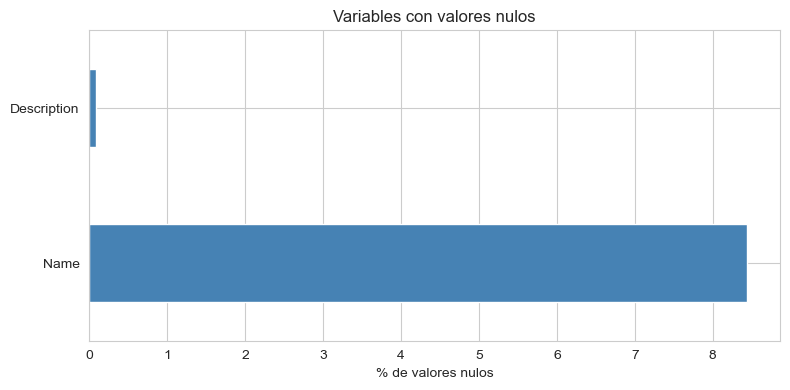

In [ ]:
# Visualización de nulos
cols_con_nulos = null_df[null_df['Nulos'] > 0]
plt.figure(figsize=(8, 4))
cols_con_nulos['Porcentaje (%)'].plot(kind='barh', color='steelblue')
plt.xlabel('% de valores nulos')
plt.title('Variables con valores nulos')
plt.tight_layout()
plt.show()

### 1.3 Mapeo de variables categóricas

Convertimos los códigos numéricos a etiquetas descriptivas para facilitar el análisis.

In [ ]:
df = train.copy()

# Mapeos según el diccionario de datos
df['Type']         = df['Type'].map({1: 'Perro', 2: 'Gato'})
df['Gender']       = df['Gender'].map({1: 'Macho', 2: 'Hembra', 3: 'Mixto'})
df['MaturitySize'] = df['MaturitySize'].map({0: 'No especif.', 1: 'Pequeño', 2: 'Mediano', 3: 'Grande', 4: 'Extra Grande'})
df['FurLength']    = df['FurLength'].map({0: 'No especif.', 1: 'Corto', 2: 'Mediano', 3: 'Largo'})
df['Vaccinated']   = df['Vaccinated'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Dewormed']     = df['Dewormed'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Sterilized']   = df['Sterilized'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['Health']       = df['Health'].map({0: 'No especif.', 1: 'Sano', 2: 'Lesión leve', 3: 'Lesión grave'})

# Unión con labels de colores y estados
color_map = colors.set_index('ColorID')['ColorName'].to_dict()
state_map = states.set_index('StateID')['StateName'].to_dict()

df['Color1'] = df['Color1'].map(color_map)
df['State']  = df['State'].map(state_map)

# Variable: tiene nombre o no
df['HasName'] = df['Name'].notna() & (df['Name'].str.strip() != '')

# Variable: es mestizo
df['IsMixed'] = (train['Breed2'] != 0).astype(int)

# Variable: tiene foto
df['HasPhoto'] = (df['PhotoAmt'].fillna(0) > 0).astype(int)

# Variable: tiene video
df['HasVideo'] = (df['VideoAmt'] > 0).astype(int)

# Variable: adopción gratuita
df['IsFree'] = (df['Fee'] == 0).astype(int)

print('Dataset preparado.')
df.head(3)

Dataset preparado.


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,HasName,IsMixed,HasPhoto,HasVideo,IsFree
0,Gato,Nibble,3,299,0,Macho,Black,7,0,Pequeño,Corto,No,No,No,Sano,1,100,Selangor,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2,True,0,1,0,0
1,Gato,No Name Yet,1,265,0,Macho,Black,2,0,Mediano,Mediano,No sabe,No sabe,No sabe,Sano,1,0,Kuala Lumpur,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0,True,0,1,0,1
2,Perro,Brisco,1,307,0,Macho,Brown,7,0,Mediano,Mediano,Sí,Sí,No,Sano,1,0,Selangor,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3,True,0,1,0,1


### 1.4 Estadísticas descriptivas

In [ ]:
df.describe()

,Age,Breed1,Breed2,Color2,Color3,Quantity,Fee,VideoAmt,PhotoAmt,AdoptionSpeed,IsMixed,HasPhoto,HasVideo,IsFree
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,10.452078,265.272594,74.009738,3.222837,1.882012,1.576069,21.259988,0.056760,3.889215,2.516441,0.282198,0.977256,0.038285,0.844594
std,18.155790,60.056818,123.011575,2.742562,2.984086,1.472477,78.414548,0.346185,3.487810,1.177265,0.450084,0.149091,0.191889,0.362303
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,265.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000
50%,3.000000,266.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,3.000000,2.000000,0.000000,1.000000,0.000000,1.000000
75%,12.000000,307.000000,179.000000,6.000000,5.000000,1.000000,0.000000,0.000000,5.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,255.000000,307.000000,307.000000,7.000000,7.000000,20.000000,3000.000000,8.000000,30.000000,4.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.describe(include='object')

,Type,Name,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,State,RescuerID,Description,PetID
count,14993,13728,14993,14993,14993,14993,14993,14993,14993,14993,14993,14993,14980,14993
unique,2,9059,3,7,4,3,3,3,3,3,14,5595,14031,14993
top,Perro,Baby,Hembra,Black,Mediano,Corto,No,Sí,No,Sano,Selangor,fa90fa5b1ee11c86938398b60abc32cb,For Adoption,86e1089a3
freq,8132,66,7277,7427,10305,8808,7227,8397,10077,14478,8714,459,164,1


---
## 2. Análisis Univariado

### 2.1 Variable target: AdoptionSpeed

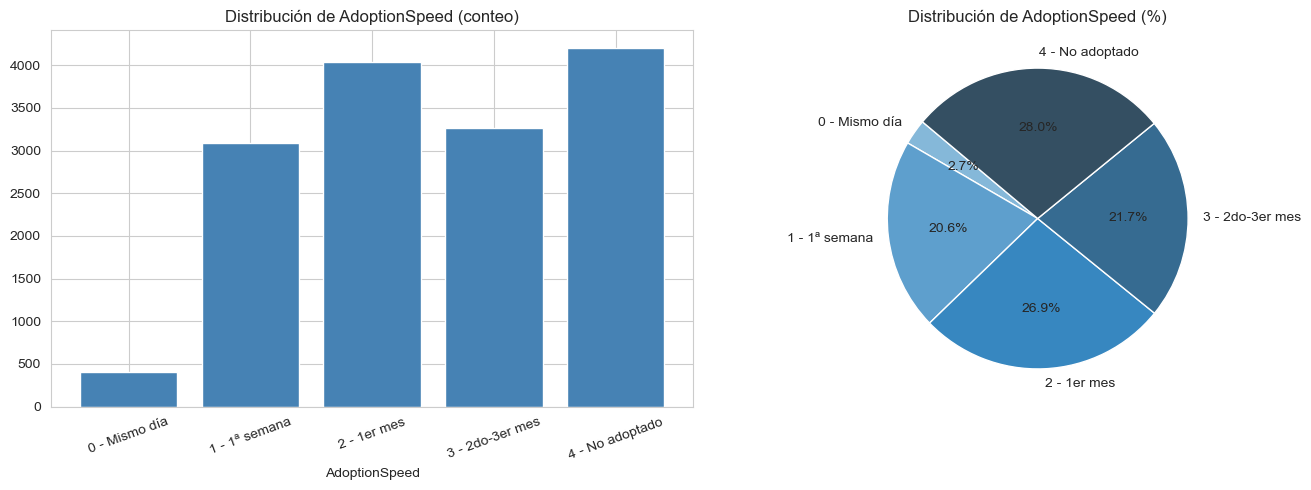


Distribución del target:


,Conteo,Porcentaje (%)
AdoptionSpeed,,
0,410,2.7
1,3090,20.6
2,4037,26.9
3,3259,21.7
4,4197,28.0


In [ ]:
target_labels = {
    0: '0 - Mismo día',
    1: '1 - 1ª semana',
    2: '2 - 1er mes',
    3: '3 - 2do-3er mes',
    4: '4 - No adoptado'
}

counts = df['AdoptionSpeed'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([target_labels[i] for i in counts.index], counts.values, color='steelblue')
axes[0].set_title('Distribución de AdoptionSpeed (conteo)')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].tick_params(axis='x', rotation=20)

axes[1].pie(pcts.values, labels=[target_labels[i] for i in pcts.index],
            autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Blues_d', 5))
axes[1].set_title('Distribución de AdoptionSpeed (%)')

plt.tight_layout()
plt.show()

print('\nDistribución del target:')
pd.DataFrame({'Conteo': counts, 'Porcentaje (%)': pcts.round(1)})

### 2.2 Tipo de animal

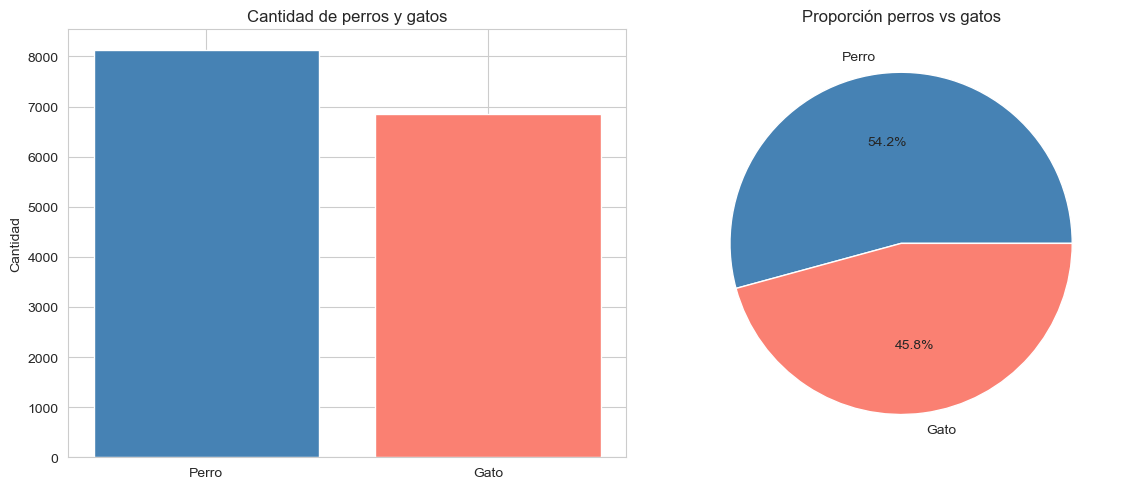

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vc = df['Type'].value_counts()
axes[0].bar(vc.index, vc.values, color=['steelblue', 'salmon'])
axes[0].set_title('Cantidad de perros y gatos')
axes[0].set_ylabel('Cantidad')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Proporción perros vs gatos')

plt.tight_layout()
plt.show()

### 2.3 Variables numéricas continuas

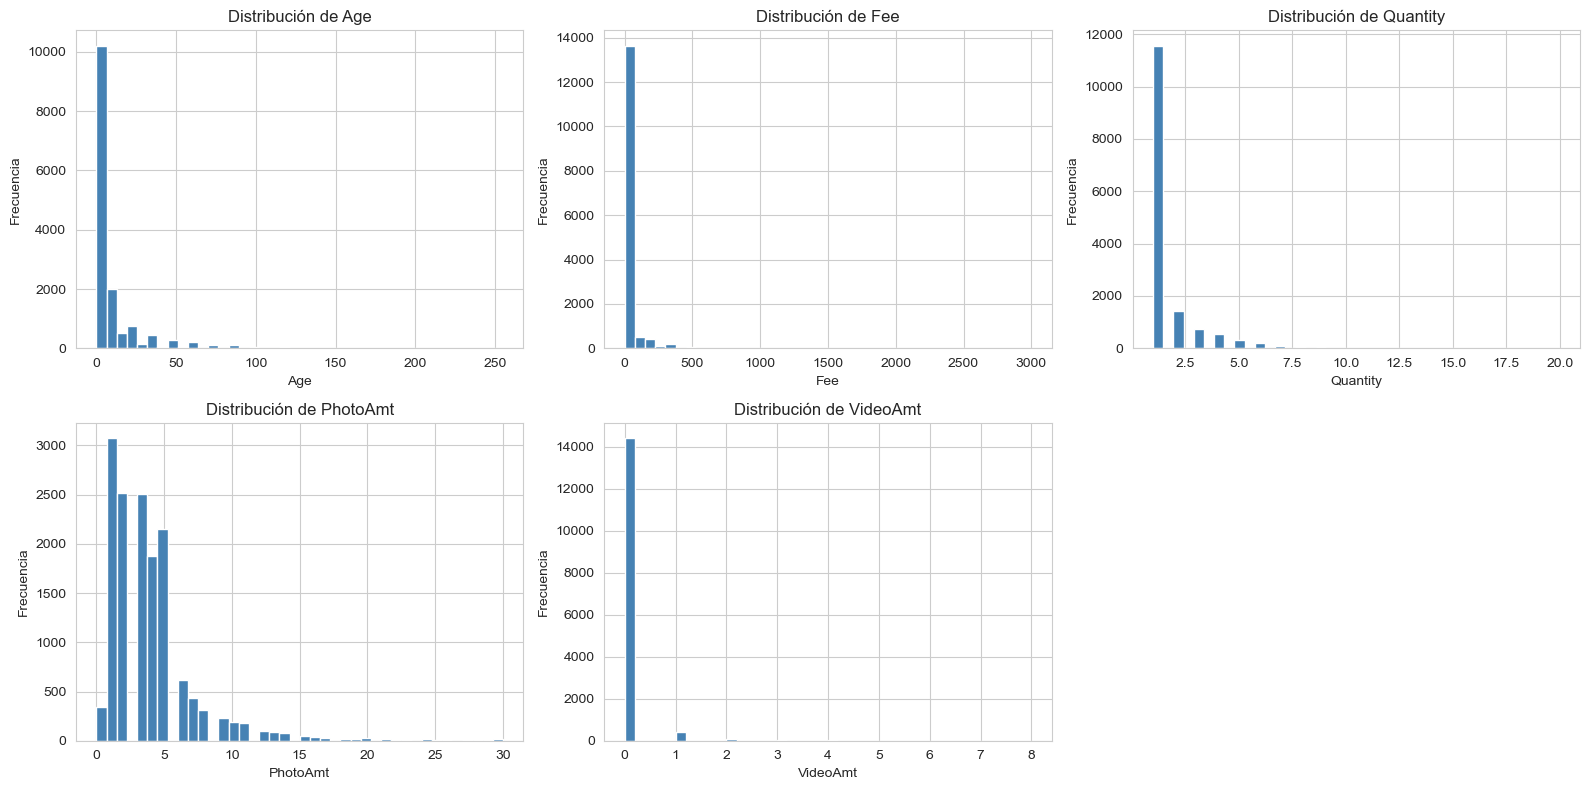

In [ ]:
num_cols = ['Age', 'Fee', 'Quantity', 'PhotoAmt', 'VideoAmt']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Estadísticas de variables numéricas clave
df[num_cols].describe().round(2)

,Age,Fee,Quantity,PhotoAmt,VideoAmt
count,14993.00,14993.00,14993.00,14993.00,14993.00
mean,10.45,21.26,1.58,3.89,0.06
std,18.16,78.41,1.47,3.49,0.35
min,0.00,0.00,1.00,0.00,0.00
25%,2.00,0.00,1.00,2.00,0.00
50%,3.00,0.00,1.00,3.00,0.00
75%,12.00,0.00,1.00,5.00,0.00
max,255.00,3000.00,20.00,30.00,8.00


### 2.4 Variables categóricas

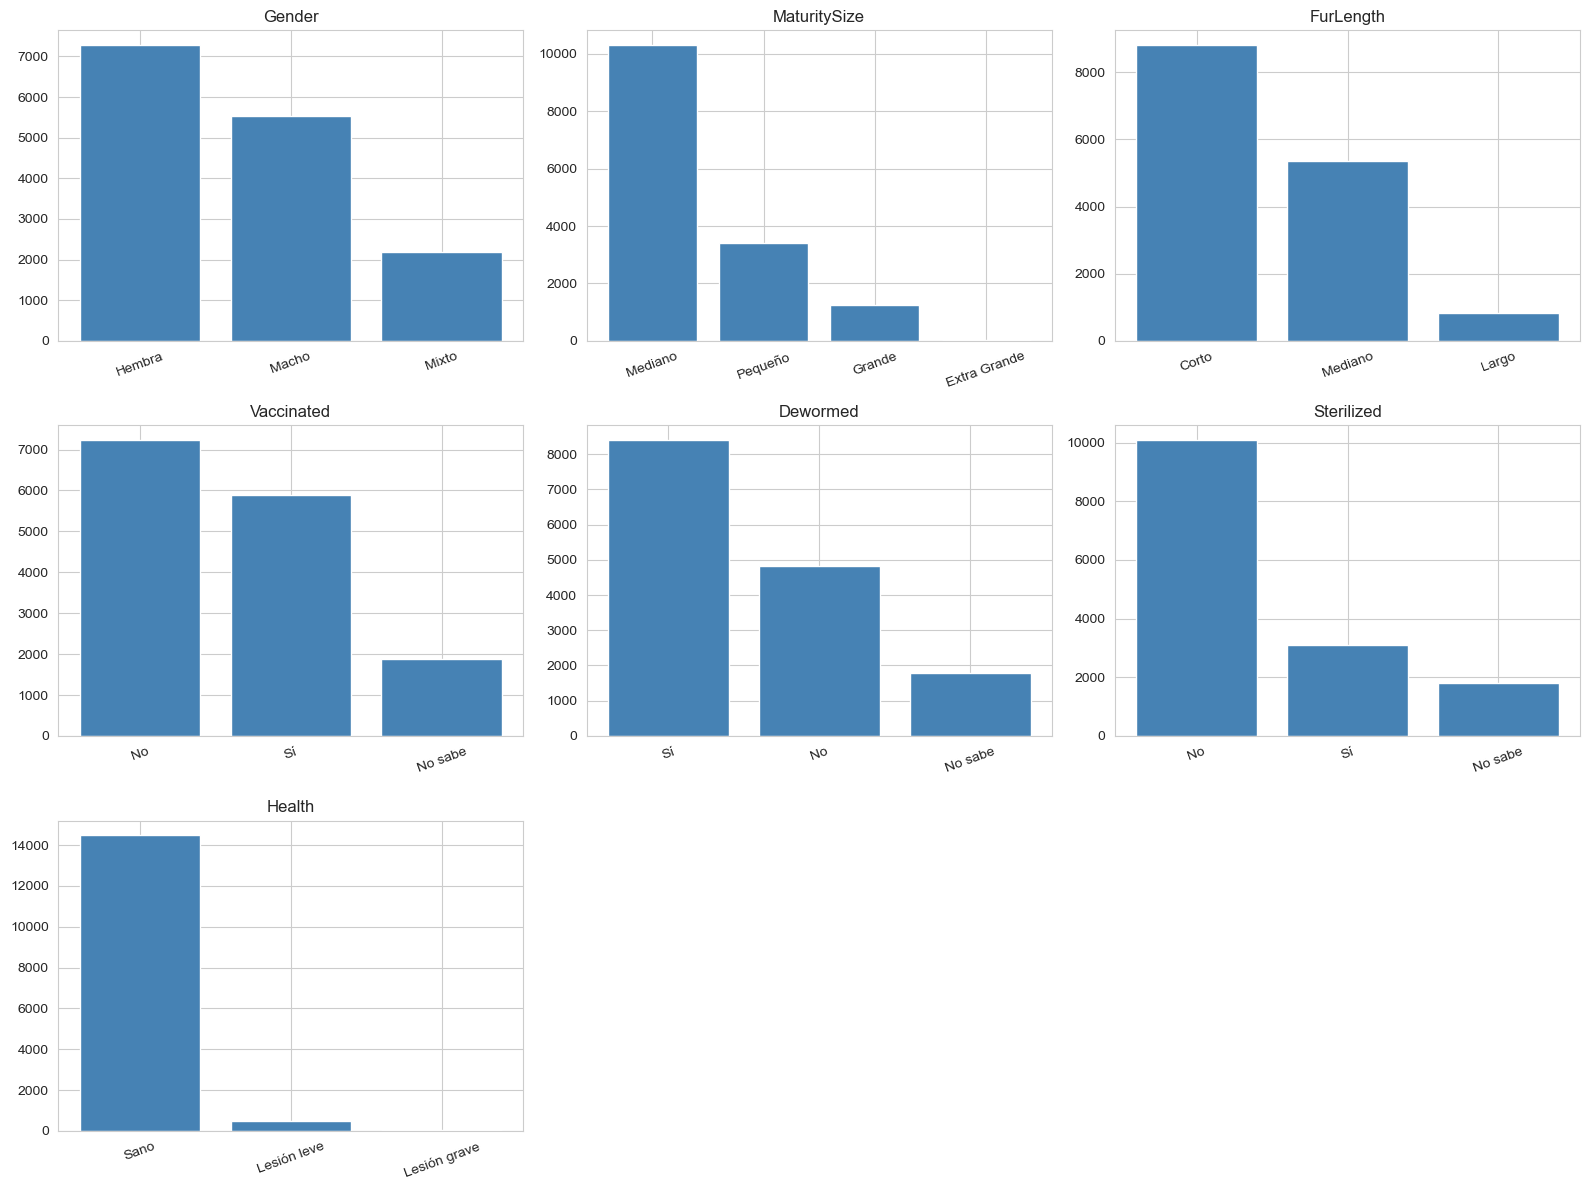

In [ ]:
cat_cols = ['Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='steelblue')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 2.5 Distribución geográfica (Estado)

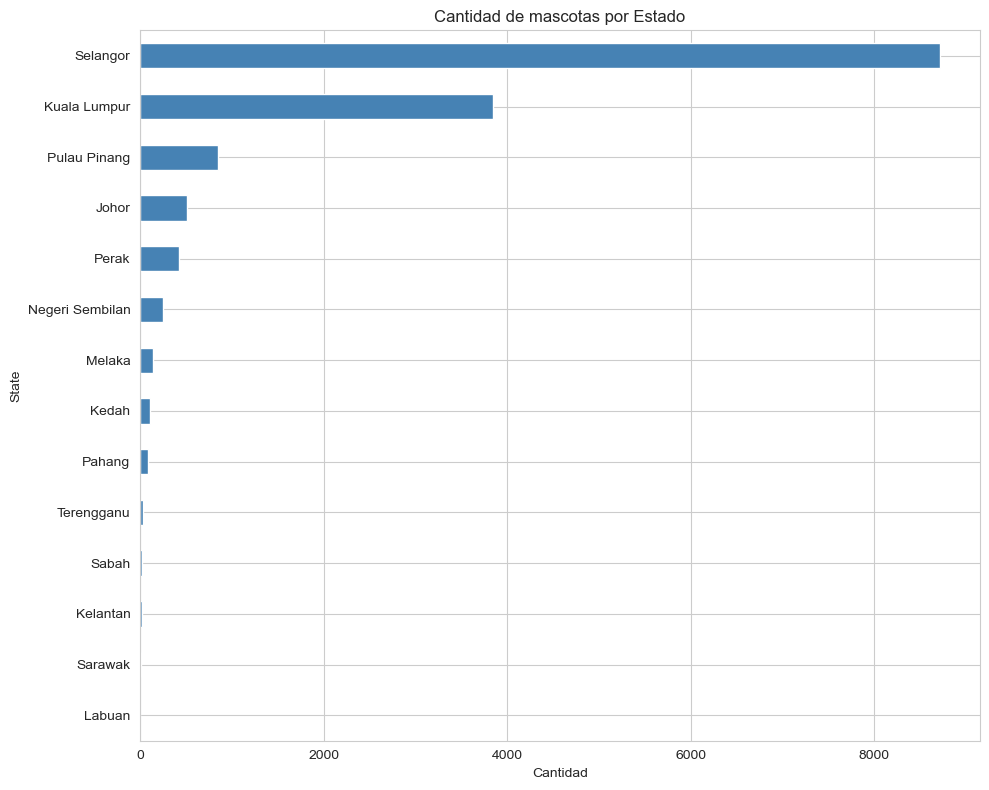

In [ ]:
state_counts = df['State'].value_counts().sort_values(ascending=True)
plt.figure(figsize=(10, 8))
state_counts.plot(kind='barh', color='steelblue')
plt.title('Cantidad de mascotas por Estado')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

### 2.6 Nombres más frecuentes

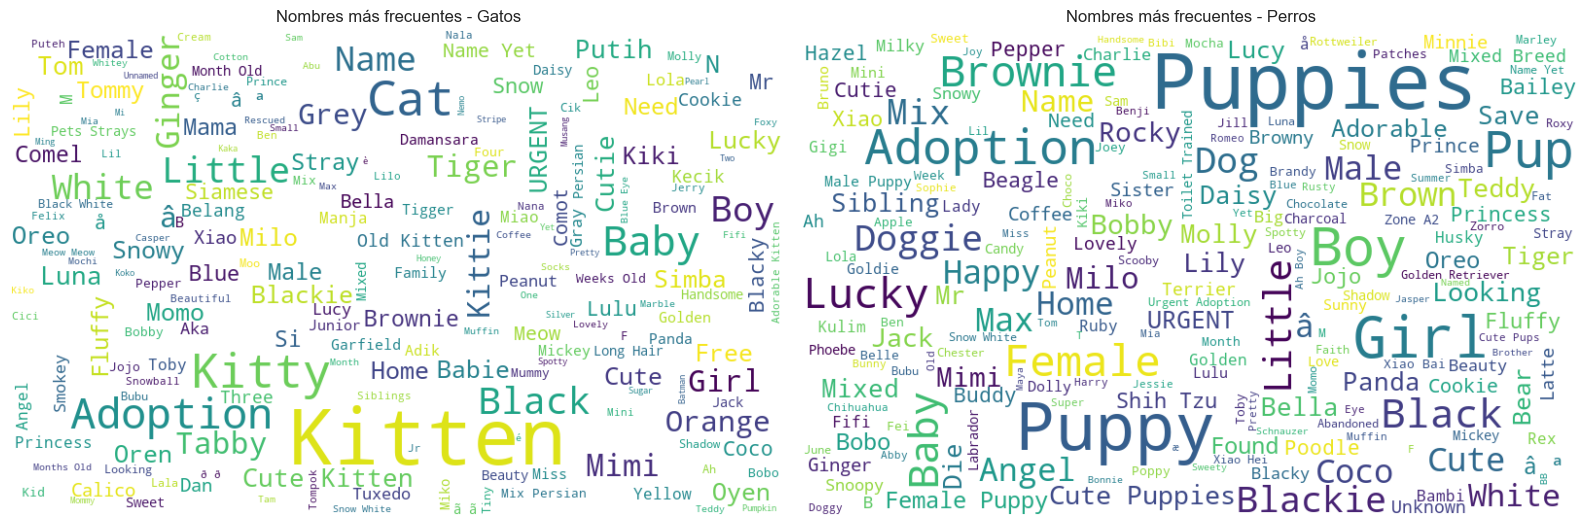

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tipo in zip(axes, ['Gato', 'Perro']):
    text = ' '.join(df.loc[df['Type'] == tipo, 'Name'].dropna().values)
    if text.strip():
        wc = WordCloud(max_font_size=80, background_color='white',
                       width=800, height=500).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Nombres más frecuentes - {tipo}s')
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## 3. Análisis Bivariado (relación con AdoptionSpeed)

In [ ]:
# Función auxiliar: tasa de adopción rápida (clases 0+1) por categoría
def adoption_rate_by(col, df=df, fast_classes=(0, 1)):
    """Calcula % de adopción rápida por categoría."""
    result = df.groupby(col)['AdoptionSpeed'].apply(
        lambda x: (x.isin(fast_classes)).mean() * 100
    ).sort_values(ascending=False)
    return result

### 3.1 AdoptionSpeed según tipo de animal

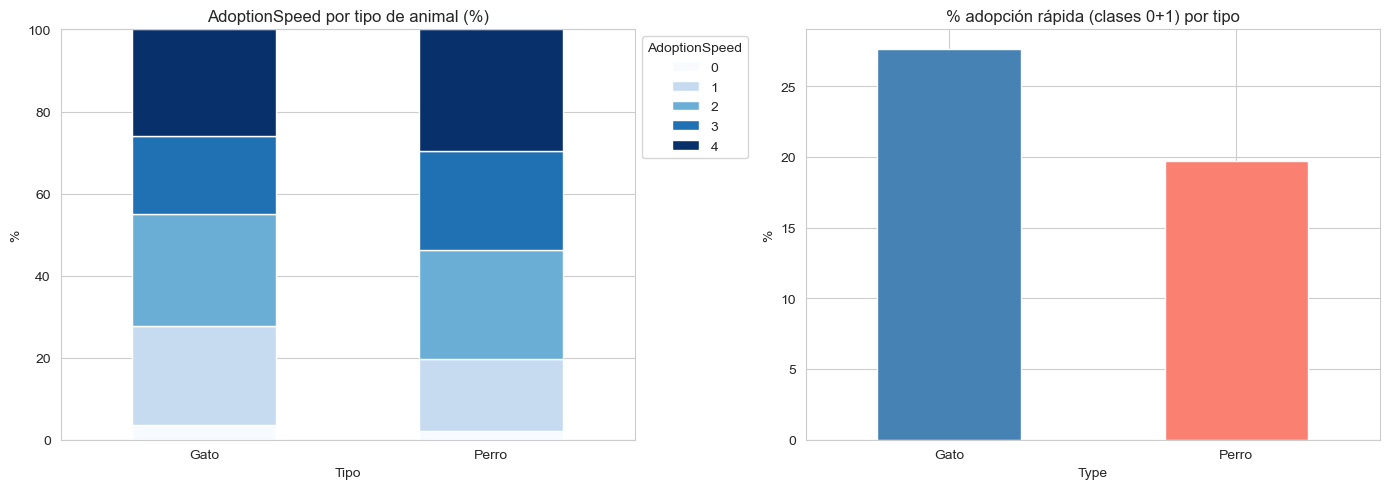

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución del target por tipo (IZQUIERDA - APILADO AL 100%)
cross = df.groupby(['Type', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

# Añadimos stacked=True para que las barras se apilen
cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('AdoptionSpeed por tipo de animal (%)')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 100) # Asegura que el eje Y llegue al 100%
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.0, 1.0)) # Mueve la leyenda si tapa el gráfico

# 2. Tasa de adopción rápida (DERECHA)
rate = adoption_rate_by('Type')
rate.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='white')
axes[1].set_title('% adopción rápida (clases 0+1) por tipo')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.2 Edad y AdoptionSpeed

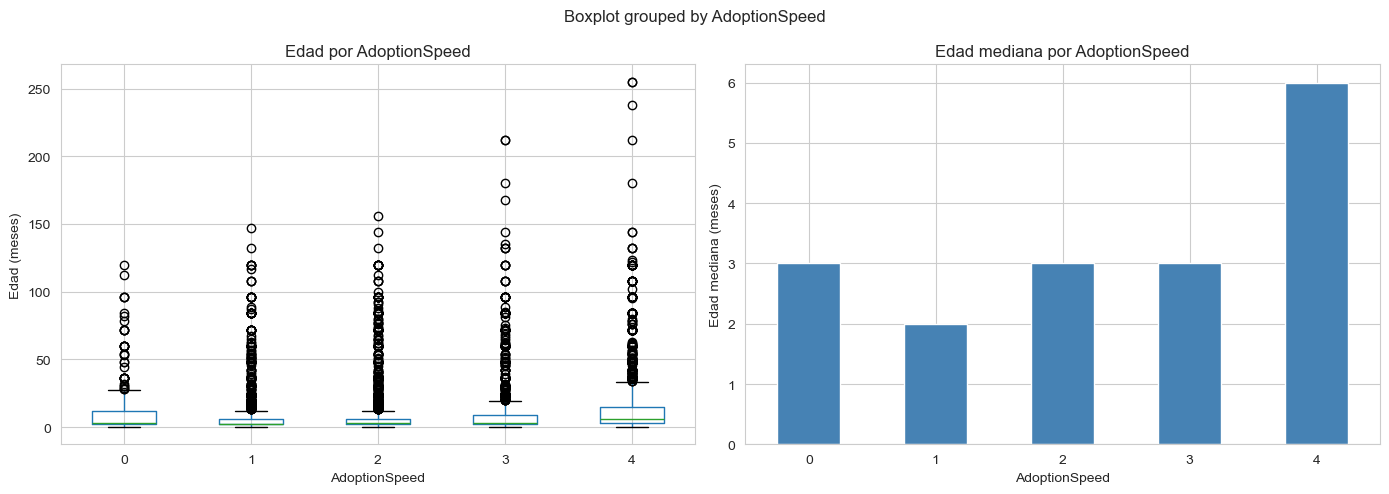

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de edad por clase de adopción
df.boxplot(column='Age', by='AdoptionSpeed', ax=axes[0])
axes[0].set_title('Edad por AdoptionSpeed')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].set_ylabel('Edad (meses)')
plt.sca(axes[0])
plt.title('Edad por AdoptionSpeed')

# Edad promedio por clase
age_mean = df.groupby('AdoptionSpeed')['Age'].median()
age_mean.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Edad mediana por AdoptionSpeed')
axes[1].set_xlabel('AdoptionSpeed')
axes[1].set_ylabel('Edad mediana (meses)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.3 Variables de salud y AdoptionSpeed

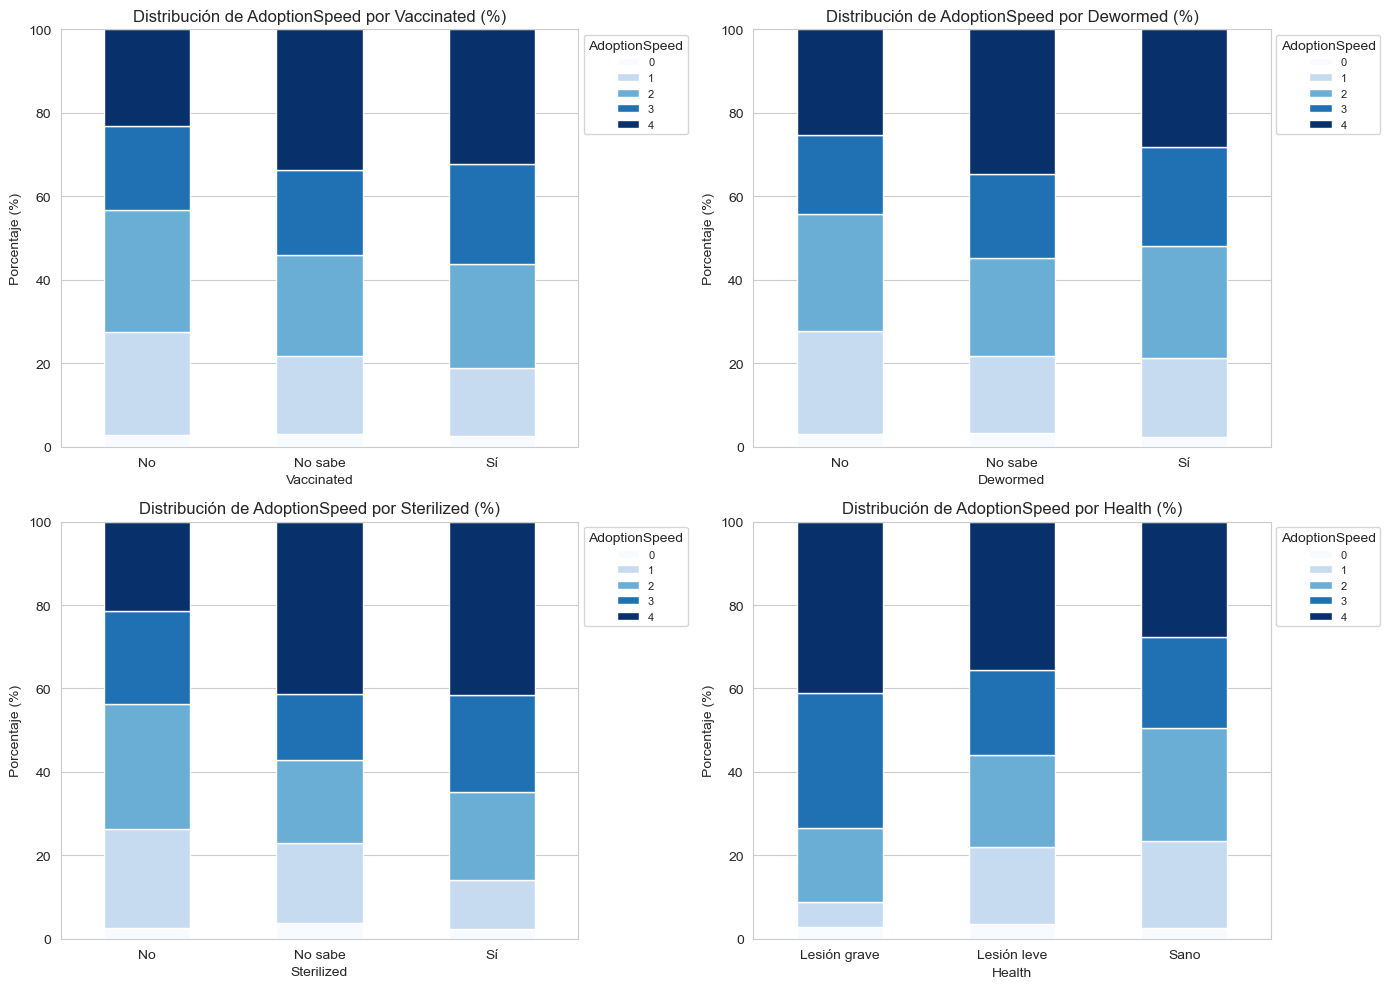

In [ ]:
health_cols = ['Vaccinated', 'Dewormed', 'Sterilized', 'Health']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(health_cols):
    # Calcular proporciones
    cross = df.groupby([col, 'AdoptionSpeed']).size().unstack(fill_value=0)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

    # Graficar con stacked=True
    cross_pct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Blues', edgecolor='white')

    # Configuración de cada subplot
    axes[i].set_title(f'Distribución de AdoptionSpeed por {col} (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=0) # Rotación 0 suele leerse mejor en categorías cortas

    # Ajustar leyenda para que no tape las barras
    axes[i].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

### 3.4 Fee (tarifa) y AdoptionSpeed

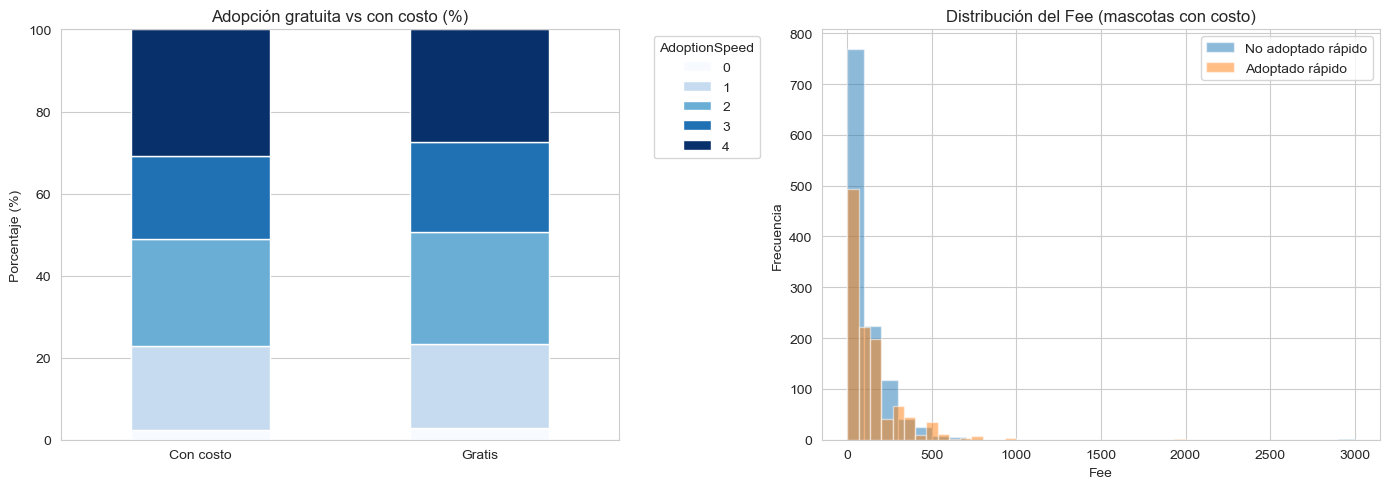

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gratis vs pago (IZQUIERDA - APILADO AL 100%)
# Asumiendo que IsFree es una columna booleana o 0/1
cross = df.groupby(['IsFree', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
# Ajustamos los índices para que coincidan con la lógica de tu dataset
cross_pct.index = ['Con costo', 'Gratis']

# Añadimos stacked=True
cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('Adopción gratuita vs con costo (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Distribución del fee para adoptados rápido vs lento (DERECHA)
df_fee = df[df['Fee'] > 0].copy()
# Definimos rápido como clases 0, 1 y 2
df_fee['Rapido'] = df_fee['AdoptionSpeed'].isin([0, 1, 2])

# Graficamos histogramas solapados
for status, group in df_fee.groupby('Rapido'):
    label = 'Adoptado rápido' if status else 'No adoptado rápido'
    axes[1].hist(group['Fee'], bins=30, alpha=0.5, label=label, edgecolor='white')

axes[1].set_title('Distribución del Fee (mascotas con costo)')
axes[1].set_xlabel('Fee')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.5 Fotos, Videos y AdoptionSpeed

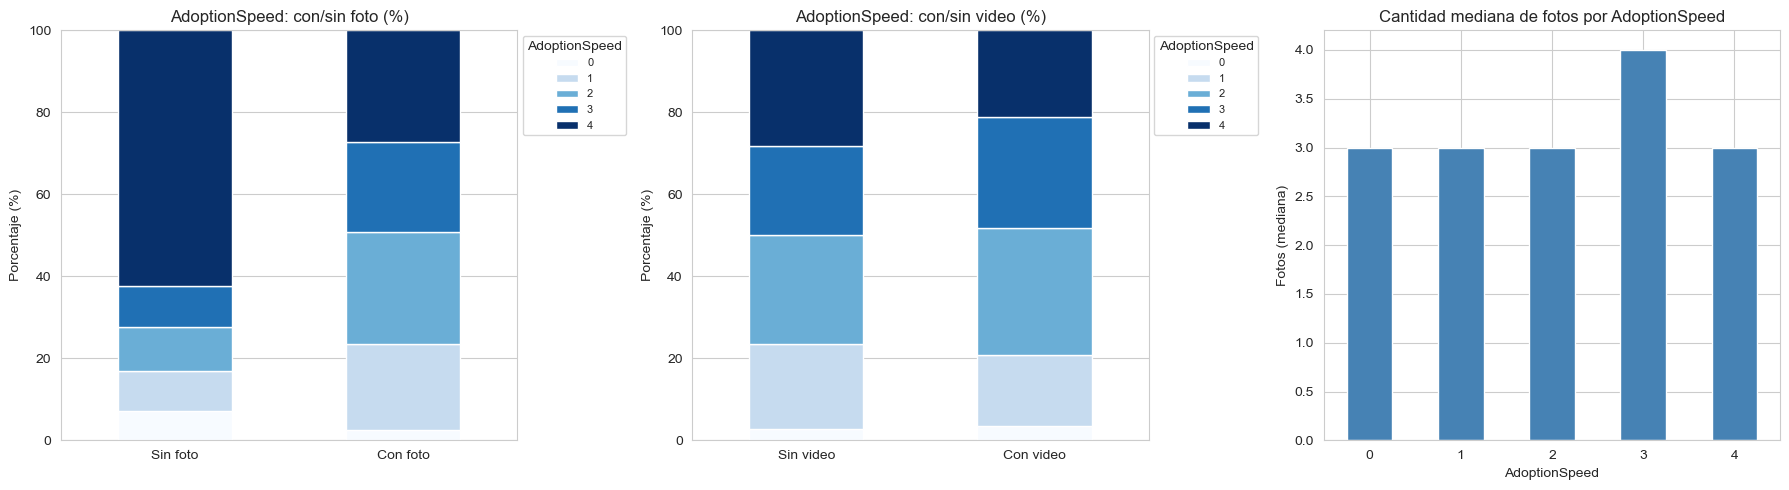

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tiene foto o no (IZQUIERDA - APILADO AL 100%)
cross = df.groupby(['HasPhoto', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Sin foto', 'Con foto']

# Aplicamos stacked=True
cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')
axes[0].set_title('AdoptionSpeed: con/sin foto (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

# 2. Tiene video o no (CENTRO - APILADO AL 100%)
cross2 = df.groupby(['HasVideo', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross2_pct = cross2.div(cross2.sum(axis=1), axis=0) * 100
cross2_pct.index = ['Sin video', 'Con video']

# Aplicamos stacked=True
cross2_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Blues', edgecolor='white')
axes[1].set_title('AdoptionSpeed: con/sin video (%)')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

# 3. Cantidad de fotos vs AdoptionSpeed (DERECHA - MEDIANA)
df.groupby('AdoptionSpeed')['PhotoAmt'].median().plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Cantidad mediana de fotos por AdoptionSpeed')
axes[2].set_xlabel('AdoptionSpeed')
axes[2].set_ylabel('Fotos (mediana)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.6 Género y AdoptionSpeed

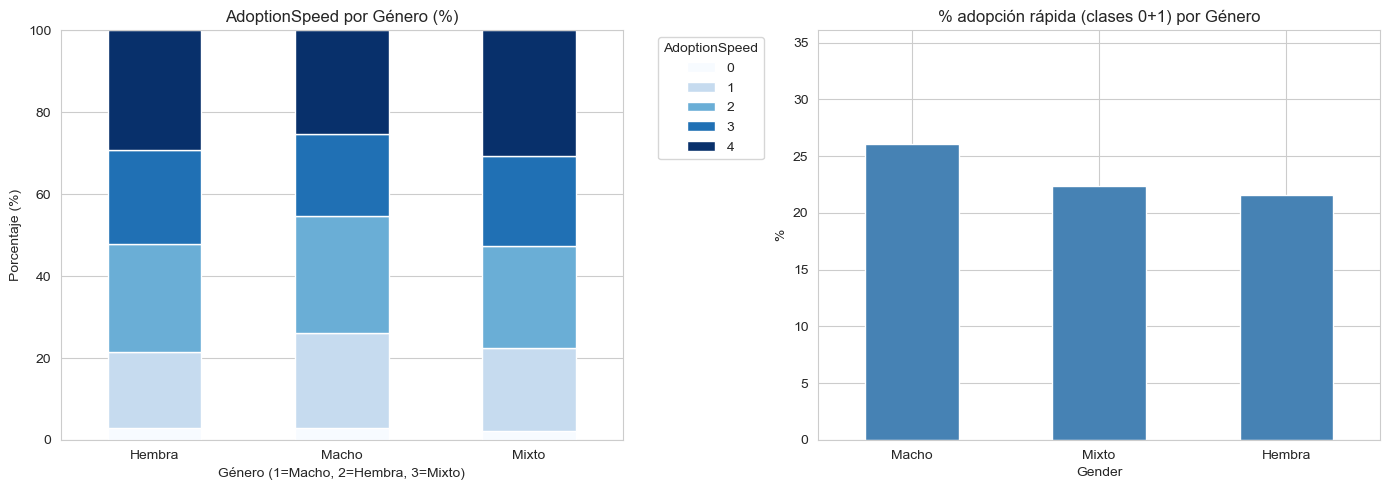

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. AdoptionSpeed por Género (IZQUIERDA - APILADO AL 100%)
cross = df.groupby(['Gender', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

# Añadimos stacked=True
cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('AdoptionSpeed por Género (%)')
axes[0].set_xlabel('Género (1=Macho, 2=Hembra, 3=Mixto)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Tasa de adopción rápida por Género (DERECHA)
rate = adoption_rate_by('Gender')
rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('% adopción rápida (clases 0+1) por Género')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, rate.max() + 10) # Ajuste dinámico del tope
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.7 Nombre y AdoptionSpeed

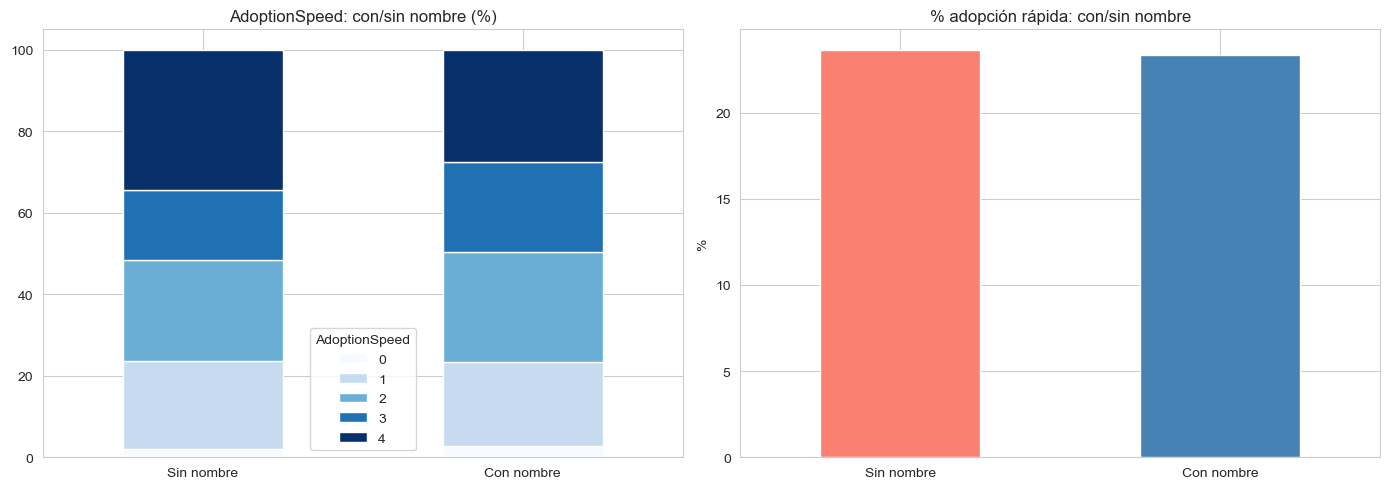

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross = df.groupby(['HasName', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Sin nombre', 'Con nombre']
cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')
axes[0].set_title('AdoptionSpeed: con/sin nombre (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed')

rate = df.groupby('HasName')['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
)
rate.index = ['Sin nombre', 'Con nombre']
rate.plot(kind='bar', ax=axes[1], color=['salmon', 'steelblue'])
axes[1].set_title('% adopción rápida: con/sin nombre')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.8 Estado geográfico y AdoptionSpeed

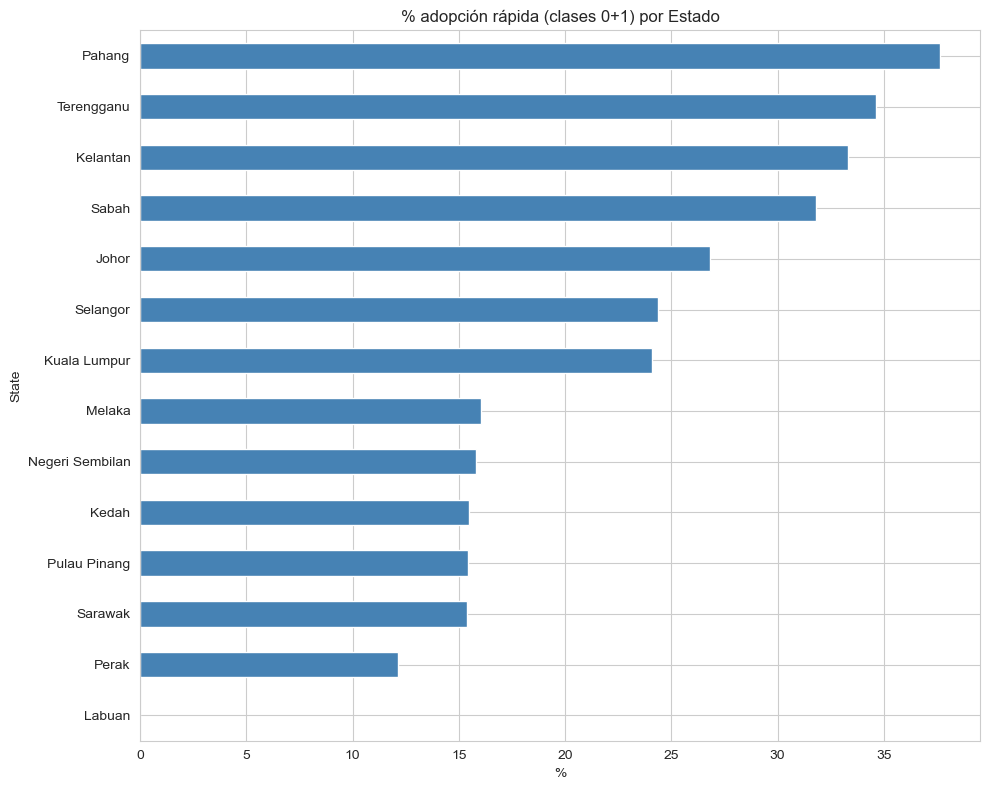

In [ ]:
rate_state = adoption_rate_by('State').sort_values()
plt.figure(figsize=(10, 8))
rate_state.plot(kind='barh', color='steelblue')
plt.title('% adopción rápida (clases 0+1) por Estado')
plt.xlabel('%')
plt.tight_layout()
plt.show()

### 3.9 Cantidad de mascotas (Quantity) y AdoptionSpeed

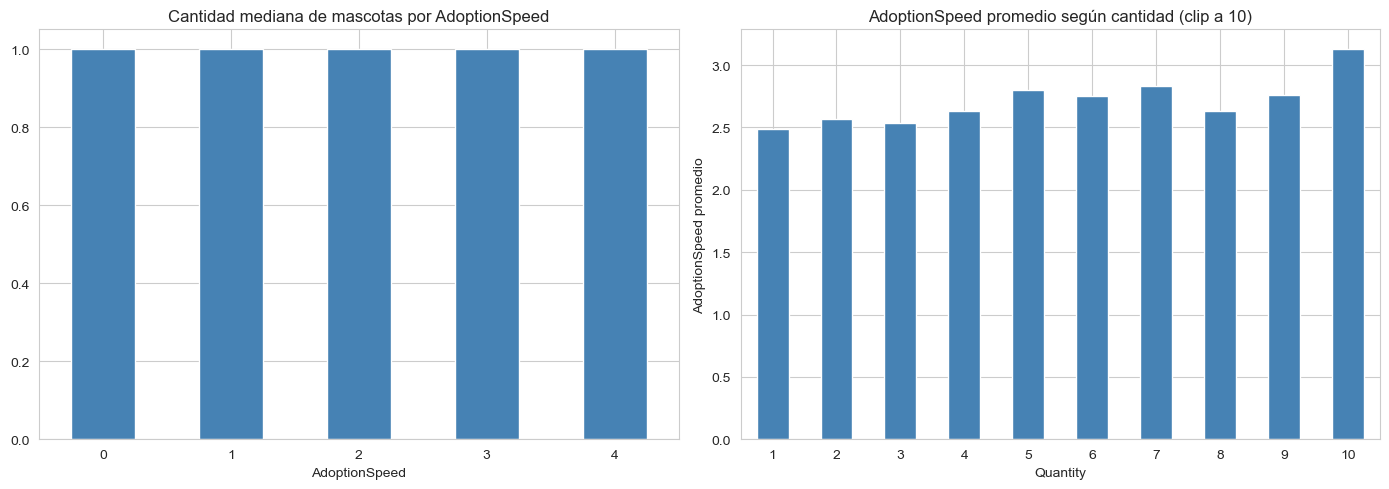

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('AdoptionSpeed')['Quantity'].median().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Cantidad mediana de mascotas por AdoptionSpeed')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].tick_params(axis='x', rotation=0)

# Distribución de quantity
q_clip = df['Quantity'].clip(upper=10)
q_cross = df.groupby(q_clip)['AdoptionSpeed'].mean()
q_cross.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('AdoptionSpeed promedio según cantidad (clip a 10)')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('AdoptionSpeed promedio')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

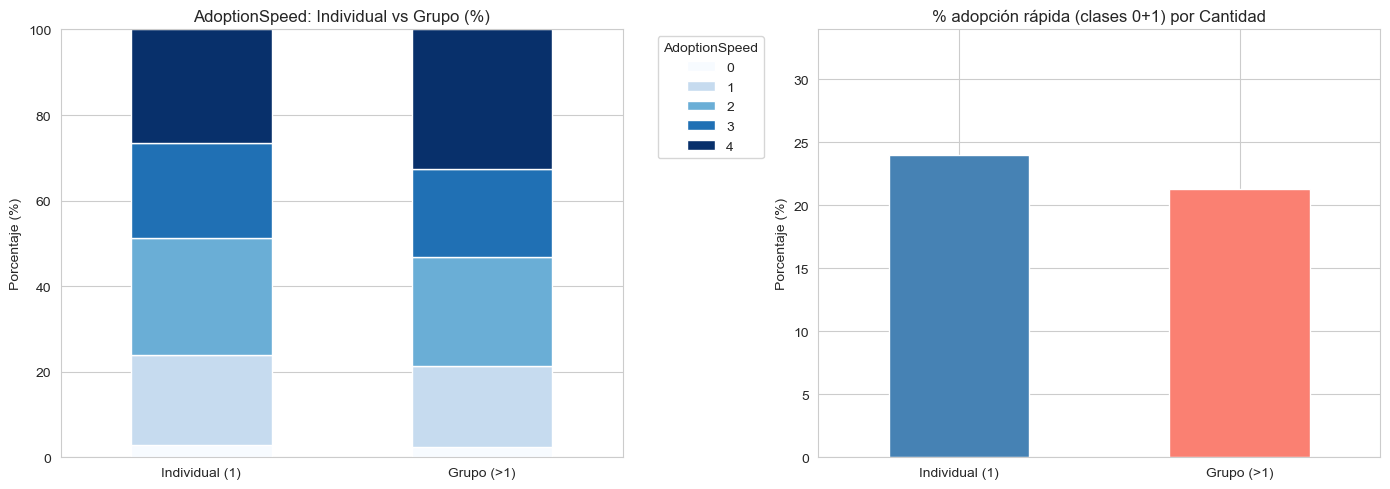

In [ ]:
# 1. Crear la variable dicotómica: 1 si es grupo (>1), 0 si es individual (==1)
df['IsGroup'] = (df['Quantity'] > 1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- GRÁFICO 1: Distribución Proporcional (Stacked 100%) ---
cross = df.groupby(['IsGroup', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Individual (1)', 'Grupo (>1)']

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('AdoptionSpeed: Individual vs Grupo (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- GRÁFICO 2: Tasa de adopción rápida (0+1) ---
rate = df.groupby('IsGroup')['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
)
rate.index = ['Individual (1)', 'Grupo (>1)']

rate.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='white')

axes[1].set_title('% adopción rápida (clases 0+1) por Cantidad')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 4. Análisis Multivariado

### 4.1 Matriz de correlación (variables numéricas)

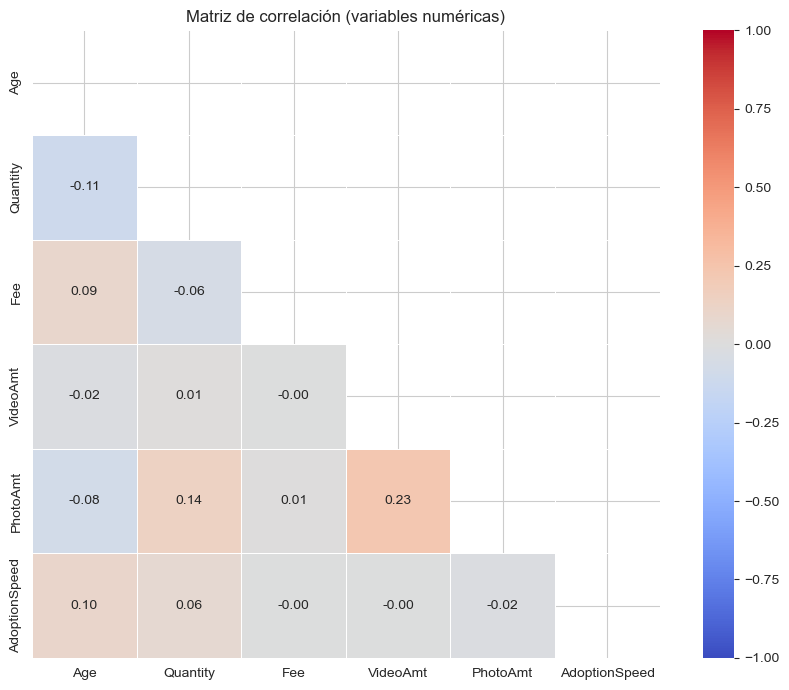

In [ ]:
num_features = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'AdoptionSpeed']
corr = df[num_features].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

### 4.2 Tipo de animal × Edad × AdoptionSpeed

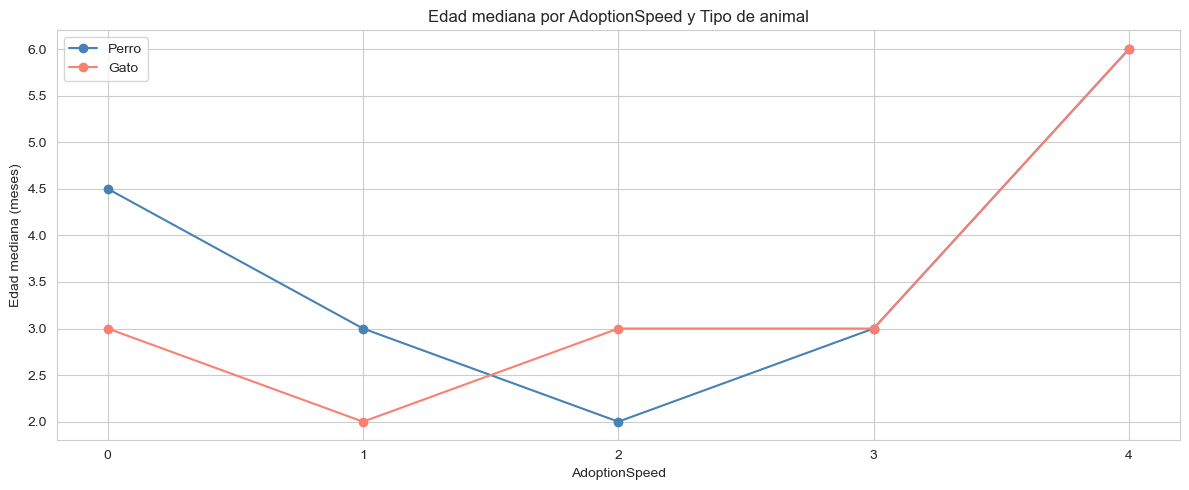

In [ ]:
plt.figure(figsize=(12, 5))
for tipo, color in [('Perro', 'steelblue'), ('Gato', 'salmon')]:
    subset = df[df['Type'] == tipo]
    mean_age = subset.groupby('AdoptionSpeed')['Age'].median()
    plt.plot(mean_age.index, mean_age.values, marker='o', label=tipo, color=color)

plt.title('Edad mediana por AdoptionSpeed y Tipo de animal')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Edad mediana (meses)')
plt.xticks([0, 1, 2, 3, 4])
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Tipo × Variables de salud × AdoptionSpeed

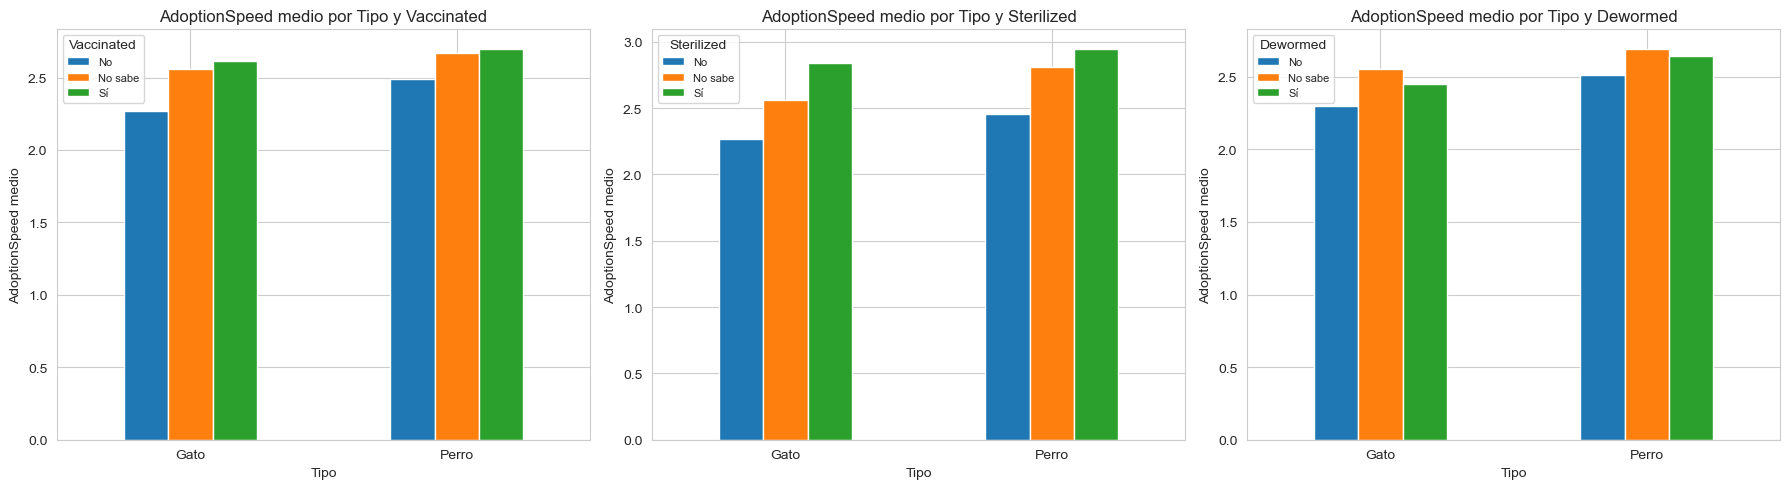

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Vaccinated', 'Sterilized', 'Dewormed']):
    pivot = df.groupby(['Type', col])['AdoptionSpeed'].mean().unstack()
    pivot.plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(f'AdoptionSpeed medio por Tipo y {col}')
    ax.set_xlabel('Tipo')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel('AdoptionSpeed medio')
    ax.legend(title=col, fontsize=8)

plt.tight_layout()
plt.show()

### 4.4 Tipo × Fee × AdoptionSpeed

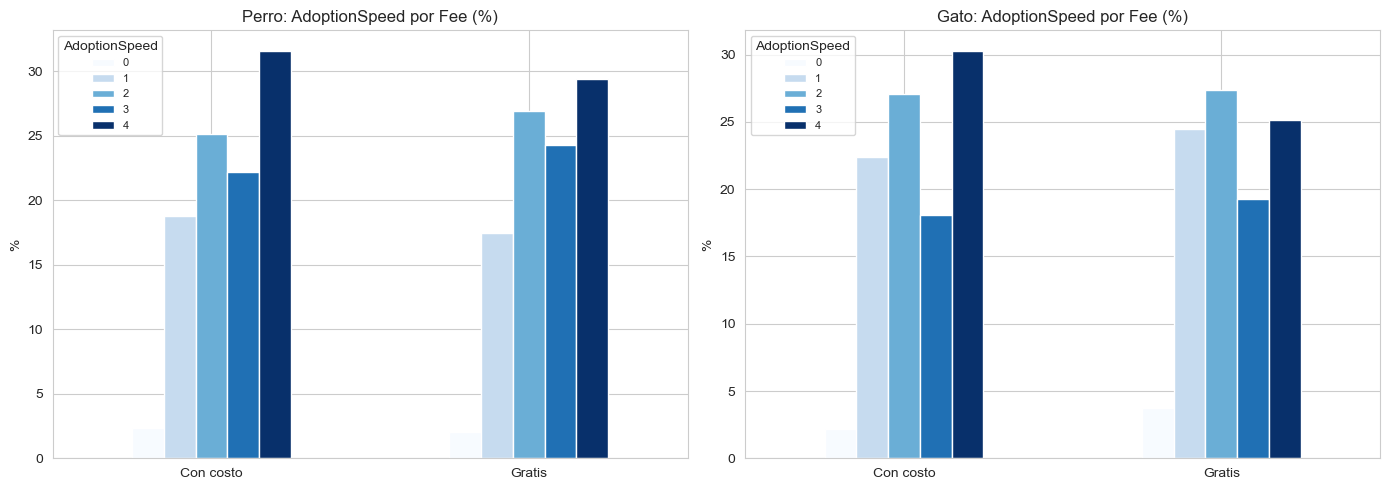

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    subset = df[df['Type'] == tipo]
    cross = subset.groupby(['IsFree', 'AdoptionSpeed']).size().unstack(fill_value=0)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.index = ['Con costo', 'Gratis']
    cross_pct.plot(kind='bar', ax=ax, colormap='Blues', edgecolor='white')
    ax.set_title(f'{tipo}: AdoptionSpeed por Fee (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel('%')
    ax.legend(title='AdoptionSpeed', fontsize=8)

plt.tight_layout()
plt.show()

### 4.5 Fotos × Tipo × AdoptionSpeed

C:\Users\carte\AppData\Local\Temp\ipykernel_12392\905222417.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()
C:\Users\carte\AppData\Local\Temp\ipykernel_12392\905222417.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()


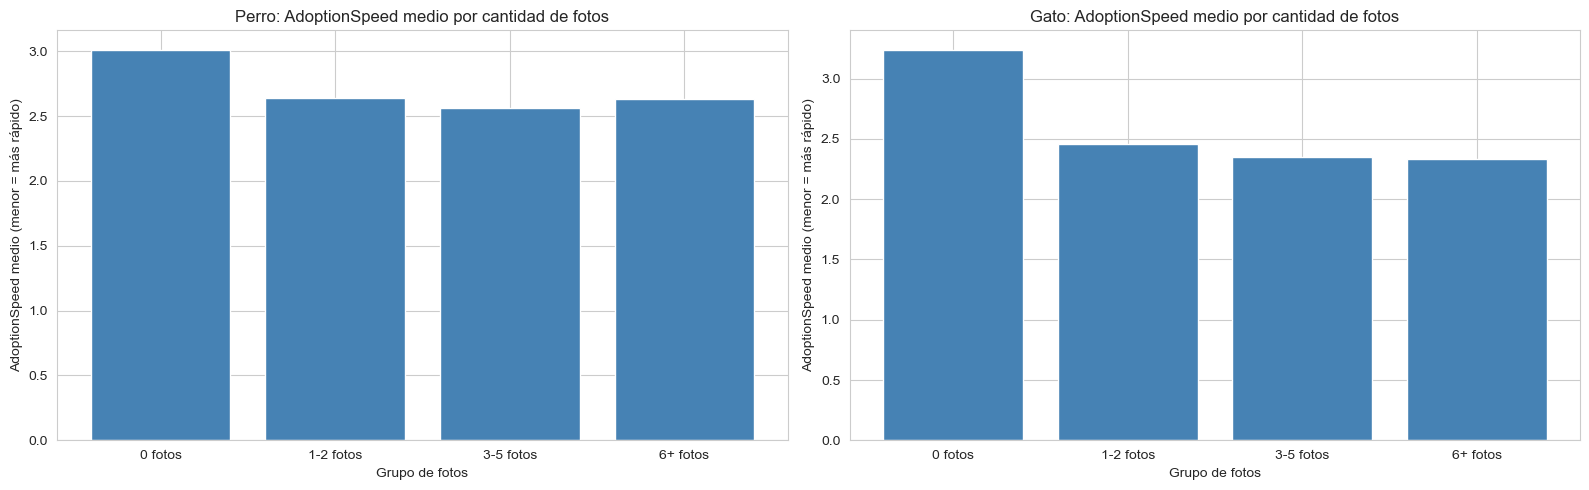

In [ ]:
# Categorizar cantidad de fotos
df['PhotoGroup'] = pd.cut(df['PhotoAmt'].fillna(0),
                           bins=[-1, 0, 2, 5, 100],
                           labels=['0 fotos', '1-2 fotos', '3-5 fotos', '6+ fotos'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    subset = df[df['Type'] == tipo]
    pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()
    ax.bar(pivot['PhotoGroup'].astype(str), pivot['AdoptionSpeed'], color='steelblue')
    ax.set_title(f'{tipo}: AdoptionSpeed medio por cantidad de fotos')
    ax.set_xlabel('Grupo de fotos')
    ax.set_ylabel('AdoptionSpeed medio (menor = más rápido)')

plt.tight_layout()
plt.show()

### 4.6 Pairplot: variables numéricas clave coloreadas por AdoptionSpeed

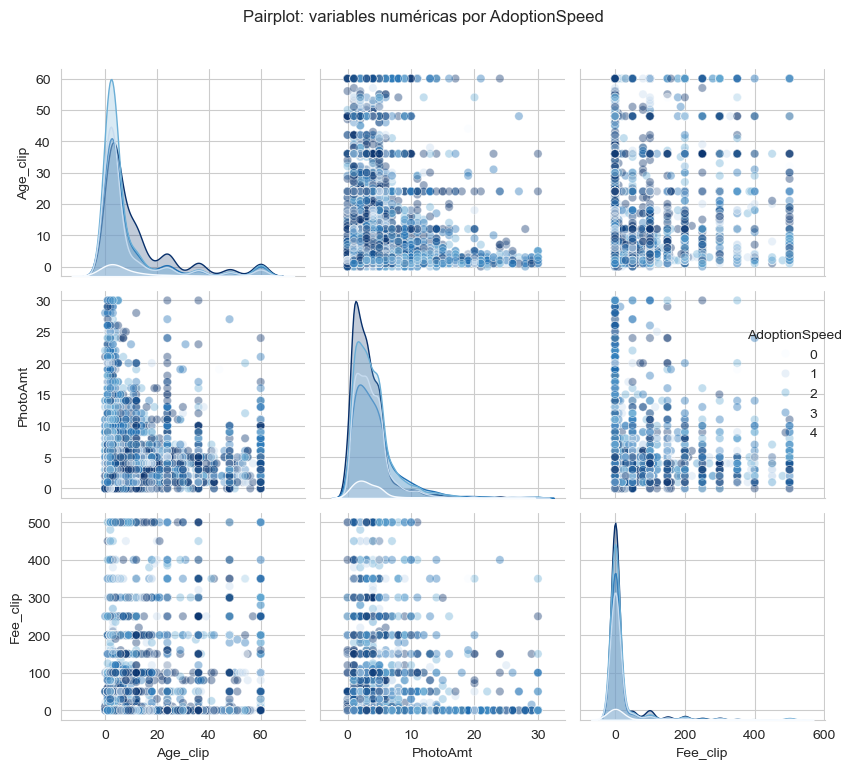

In [ ]:
pair_cols = ['Age', 'PhotoAmt', 'Fee', 'AdoptionSpeed']
pair_df = df[pair_cols].copy()
pair_df['PhotoAmt'] = pair_df['PhotoAmt'].fillna(0)
pair_df['Fee_clip'] = pair_df['Fee'].clip(upper=500)
pair_df['Age_clip'] = pair_df['Age'].clip(upper=60)

g = sns.pairplot(pair_df[['Age_clip', 'PhotoAmt', 'Fee_clip', 'AdoptionSpeed']],
                 hue='AdoptionSpeed', palette='Blues', plot_kws={'alpha': 0.4},
                 diag_kind='kde')
g.fig.suptitle('Pairplot: variables numéricas por AdoptionSpeed', y=1.02)
plt.tight_layout()
plt.show()

### 4.7 Heatmap: tasa de adopción rápida por Estado y Tipo

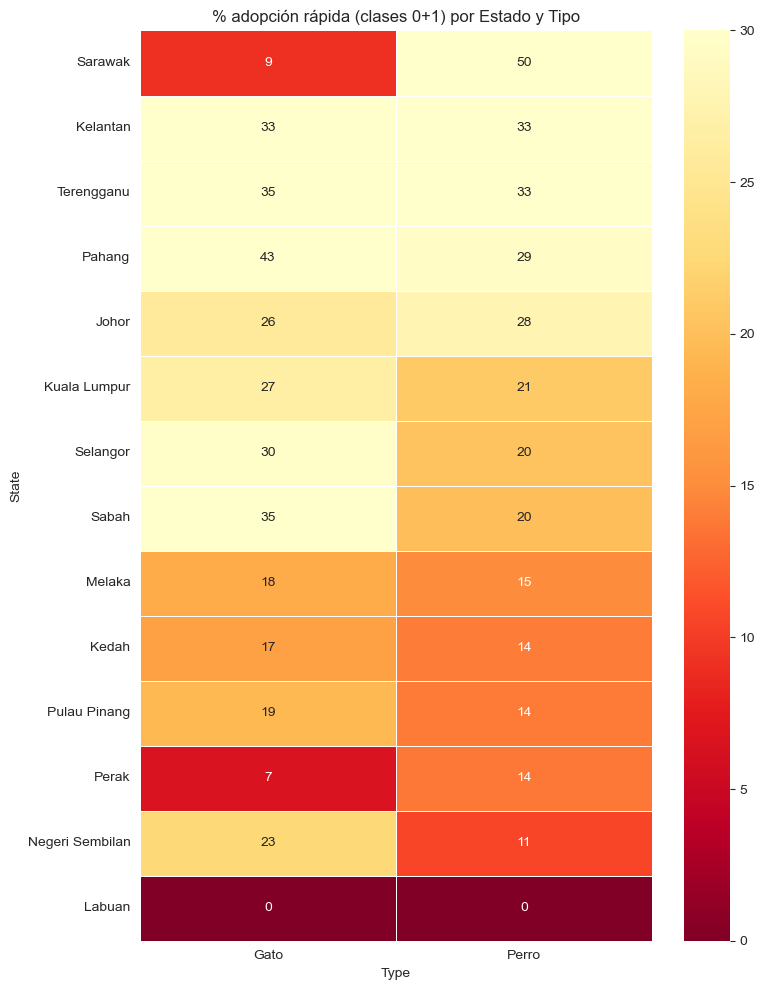

In [ ]:
pivot_state = df.groupby(['State', 'Type'])['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
).unstack()

plt.figure(figsize=(8, 10))
sns.heatmap(pivot_state.sort_values('Perro', ascending=False),
            annot=True, fmt='.0f', cmap='YlOrRd_r',
            linewidths=0.5, vmin=0, vmax=30)
plt.title('% adopción rápida (clases 0+1) por Estado y Tipo')
plt.tight_layout()
plt.show()

---
## 5. Resumen y conclusiones preliminares

### Hallazgos principales

**Sobre el target:**
- Las clases 2 y 3 (adopción en 1er mes o en 2do-3er mes) son las más frecuentes. La distribución no es uniforme.
- Solo una pequeña proporción se adopta el mismo día (clase 0).

**Variables más relevantes para el modelo:**
- **Tipo**: Los gatos tienden a tener velocidades de adopción distintas a los perros; conviene modelar con esta variable.
- **Edad**: Las mascotas más jóvenes se adoptan más rápido. Variable continua con sesgo hacia valores bajos.
- **Fotos**: Tener fotos (y más fotos) se asocia con adopciones más rápidas.
- **Fee**: Las mascotas gratuitas tienden a adoptarse de forma diferente a las que tienen costo.
- **Vacunación / Esterilización / Desparasitación**: Las mascotas con estado conocido (Sí/No) se adoptan más rápido que las de estado "No sabe".
- **Nombre**: Tener nombre muestra una leve diferencia en velocidad de adopción.
- **Estado geográfico**: Hay variación regional importante.

**Consideraciones para el modelado:**
- `PhotoAmt` tiene valores nulos — imputar con 0.
- Variables categóricas ordinales (`Vaccinated`, `Sterilized`, etc.) necesitan encoding cuidadoso.
- `Age` y `Fee` tienen distribuciones con cola larga — considerar transformaciones o clipping.
- `RescuerID` tiene alta cardinalidad — requiere encoding especial (target encoding o embeddings).
- `Description` es texto libre — puede ser fuente de señal adicional mediante NLP.
- Las imágenes disponibles (`PhotoAmt > 0`) pueden aportar señal visual.
- Crear variable tipo idioma de la descripción - Ver sentiment - Normalizar todo al inglés